# **Solução de CAPTCHAs com CNN**

Este projeto implementa uma rede neural convolucional (CNN) para resolver CAPTCHAs automaticamente. O modelo é treinado para reconhecer caracteres em imagens de CAPTCHA e convertê-los em texto.

## **Fonte dos Dados**

Os dados utilizados para o treinamento foram retirados do seguinte conjunto de dados do Kaggle:  [CAPTCHA Images](https://www.kaggle.com/datasets/fournierp/captcha-version-2-images).


## **Importações de Bibliotecas**

Nesta seção, importamos as bibliotecas necessárias para processar as imagens, construir e treinar a rede neural convolucional (CNN), além de manipular os dados e visualizar os resultados.


In [1]:
import tensorflow.compat.v1 as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import string
import os 
import cv2
import warnings

warnings.filterwarnings("ignore")
tf.disable_v2_behavior()


Instructions for updating:
non-resource variables are not supported in the long term


## **Carregamento e Visualização dos Dados**

Vamos carregar as imagens do conjunto de dados e visualizar alguns exemplos para entender o formato dos CAPTCHAs. Também converteremos as imagens para escala de cinza e ajustaremos seu tamanho conforme necessário.

### **Dimensões Originais**
- **Entrada original:** `(1070, 50, 200)` — 1070 imagens de tamanho 50x200.

In [2]:
amostras = os.listdir('base')
amostras

['226md.png',
 '22d5n.png',
 '2356g.png',
 '23mdg.png',
 '23n88.png',
 '243mm.png',
 '244e2.png',
 '245y5.png',
 '24f6w.png',
 '24pew.png',
 '25257.png',
 '253dc.png',
 '25egp.png',
 '25m6p.png',
 '25p2m.png',
 '25w53.png',
 '264m5.png',
 '268g2.png',
 '28348.png',
 '28x47.png',
 '2b827.png',
 '2bg48.png',
 '2cegf.png',
 '2cg58.png',
 '2cgyx.png',
 '2en7g.png',
 '2enf4.png',
 '2fxgd.png',
 '2g783.png',
 '2g7nm.png',
 '2gyb6.png',
 '2mg87.png',
 '2mpnn.png',
 '2n73f.png',
 '2nbc5.jpg',
 '2nbcx.png',
 '2nf26.png',
 '2npg6.png',
 '2nx38.png',
 '2p2y8.png',
 '2pfpn.png',
 '2w4y7.png',
 '2wc38.png',
 '2wx73.png',
 '2x7bm.png',
 '2xc2n.png',
 '2ycn8.png',
 '2yggg.png',
 '325fb.png',
 '32cnn.png',
 '32dnn.png',
 '33b22.png',
 '33f7m.png',
 '33n73.png',
 '33ng4.png',
 '33p4e.png',
 '34b84.png',
 '34fxm.png',
 '34pcn.png',
 '368y5.png',
 '36bc2.png',
 '36nx4.png',
 '36w25.png',
 '373gb.png',
 '377xx.png',
 '378e5.png',
 '37d52.png',
 '37ep6.png',
 '387g2.png',
 '38n57.png',
 '3b4we.png',
 '3bd8

In [3]:
imagens = []

for i in amostras:
    path = "base/" + i
    img = cv2.imread(path) # leitura da imagem
    imagens.append(img) # adiciona a imagem na lista de imagens

In [4]:
# Verificando o shape da imagem
imagens[0].shape # (altura, largura, canais de cor)

(50, 200, 3)

In [5]:
# Mostrando a imagem
cv2.imshow('Imagem', imagens[0])
cv2.waitKey(0) # espera pressionar uma tecla
cv2.destroyAllWindows() # fecha a imagem

In [6]:
# Provando que as imagens estão em RGB em vez de escala de cinza
(b, g, r) = cv2.split(imagens[0]) # separa os canais de cor
zeros = np.zeros(imagens[0].shape[:2], dtype="uint8") 

cv2.imshow("Red", cv2.merge([zeros, zeros, r])) # mostra o canal vermelho
cv2.imshow("Green", cv2.merge([zeros, g, zeros])) # mostra o canal verde
cv2.imshow("Blue", cv2.merge([b, zeros, zeros])) # mostra o canal azul

cv2.waitKey(0) # espera pressionar uma tecla
cv2.destroyAllWindows() # fecha a imagem

In [7]:
# Convertendo as imagens para escala de cinza
imagens_gray = []

for i in imagens:
    img_gray = cv2.cvtColor(i, cv2.COLOR_BGR2GRAY) # converte para escala de cinza
    imagens_gray.append(img_gray) # adiciona a imagem na lista de imagens em escala de cinza

In [8]:
len(imagens_gray) # verifica o tamanho da lista de imagens em escala de cinza

1070

In [9]:
imagens_gray[0].shape # verifica o shape da imagem em escala de cinza

(50, 200)

In [10]:
# Mostrando a imagem em escala de cinza
cv2.imshow('Imagem', imagens_gray[0])
cv2.waitKey(0) # espera pressionar uma tecla
cv2.destroyAllWindows() # fecha a imagem

In [11]:
# Visualizando cada caractere separadamente
cv2.imshow('Imagem', imagens_gray[0][12:50, 30:50]) 
cv2.waitKey(0) # espera pressionar uma tecla
cv2.destroyAllWindows() # fecha a imagem

### **Etapas de Transformação**

1. **Dividir cada imagem em 5 partes horizontais** (supõe-se que os 5 caracteres estão lado a lado).
2. Cada imagem de `(50, 200)` é dividida em **5 subimagens de tamanho `(50, 40)`** (200 ÷ 5 = 40).
3. Após a divisão:
   - Total de imagens: `1070 × 5 = 5350`
   - Dimensão final: `(5350, 50, 40)`

In [12]:
# Separando cada caractere em uma imagem distinta
x_novo = np.zeros((len(amostras)*5, 38, 20)) # (número de amostras * 5, altura, largura)
inicio_x, inicio_y, w, h = 30, 12, 20, 50 # coordenadas da imagem

for i in range(len(imagens_gray)):
    px = inicio_x
    for j in range(5):
        x_novo[i*5+j] = imagens_gray[i][inicio_y:h, px:px+w] # recorta os caracteres
        px += w 

In [13]:
x_novo.shape # verifica o shape da imagem recortada

(5350, 38, 20)

In [14]:
# Mostrando uma imagem cinza e os respectivos caracteres
cv2.imshow('Imagem', imagens_gray[1]) # mostra a imagem em escala de cinza
cv2.imshow('Imagem', x_novo[5]) 
cv2.imshow('Imagem', x_novo[6])
cv2.imshow('Imagem', x_novo[7])
cv2.imshow('Imagem', x_novo[8])
cv2.imshow('Imagem', x_novo[9])

cv2.waitKey(0) # espera pressionar uma tecla
cv2.destroyAllWindows() # fecha a imagem

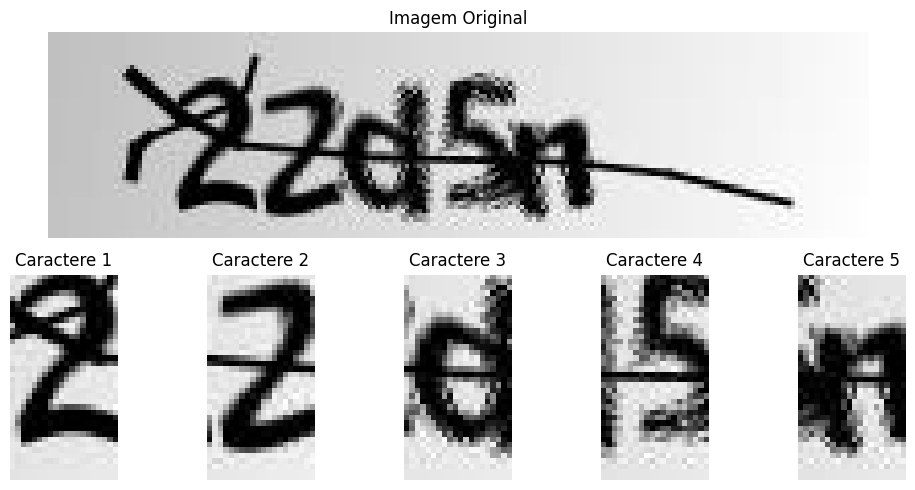

In [15]:
plt.figure(figsize=(10, 5))

# Mostrando a imagem original
plt.subplot(2, 1, 1)  # Configuração para a imagem principal
plt.imshow(imagens_gray[1], cmap='gray')
plt.title("Imagem Original")
plt.axis('off')

# Mostrando os caracteres individualmente na segunda linha
for i in range(5):
    plt.subplot(2, 5, i + 6)  # Configuração para os caracteres (segunda linha)
    plt.imshow(x_novo[5 + i], cmap='gray')
    plt.title(f"Caractere {i + 1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Pré-processamento dos Dados**

Nesta etapa, preparamos os dados para o treinamento:

- Redimensionamos as imagens
- Normalizamos os pixels
- Codificamos os rótulos (one-hot encoding)
- Dividimos os dados em treino e teste


In [16]:
# Preparando as imagens para a rede neural (normalizando e mudando o shape)

x = np.zeros((x_novo.shape[0], x_novo.shape[1], x_novo.shape[2], 1)) # (número de amostras, altura, largura, canais de cor)

for i in range(x_novo.shape[0]): # para cada imagem
    norm = x_novo[i] / 255 # normaliza a imagem
    img = np.reshape(x_novo[i], (x_novo.shape[1], x_novo.shape[2], 1)) # cria uma dimensao extra para indicar que é uma imagem em escala de cinza
    x[i] = img # adiciona a imagem na lista de imagens

In [17]:
x.shape

(5350, 38, 20, 1)

In [18]:
# Criando a variável targetr
y_atual = amostras

In [19]:
y_atual[0][0:5] 

'226md'

In [20]:
# Removendo o .png no final de cada nome de imagem
for i in range (len(y_atual)):
    y_atual[i] = y_atual[i][0:5] 

In [21]:
y_atual[0]

'226md'

In [22]:
len(y_atual) # verifica o tamanho da lista de imagens

1070

In [23]:
# Precisamos separa cada um dos valores de y_atual, para ficar com uma única lista de 5350 valores:
y = [None] * x.shape[0] # cria uma lista de None com o tamanho de x
for i in range(len(y_atual)):
    for j in range(5):
        y[i*5+j] = y_atual[i][j] # adiciona os valores na lista de y

In [24]:
len(y)

5350

In [25]:
# Precisamos fazer o one hot encoding para os valores de y
# Para isso, vamos usar definir quais são os valores possíveis de y
simbolos = string.ascii_lowercase + string.digits # letras maiúsculas e números

In [26]:
simbolos

'abcdefghijklmnopqrstuvwxyz0123456789'

In [27]:
simbolos.find('a') # verifica a posição do caractere 'a'

0

In [28]:
y_final = np.zeros((len(y), len(simbolos))) # cria uma matriz de zeros com o tamanho de y e simbolos
for i in range(len(y)):
    caractere = y[i] # pega o caractere
    loc_caractere = simbolos.find(caractere) # acha a posição do caractere
    y_final[i][loc_caractere] = 1 # adiciona 1 na posição do caractere

In [29]:
y_final[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0.])

In [30]:
y_final.shape

(5350, 36)

In [31]:
# Separando os dados em treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y_final, test_size=0.3, random_state=42)

In [32]:
x_treino.shape # verifica o tamanho do conjunto de treino


(3745, 38, 20, 1)

## **Construção da Rede Neural Convolucional (CNN)**

Aqui definimos a arquitetura da nossa CNN com TensorFlow v1. A rede é composta por camadas convolucionais, pooling, dropout e uma camada totalmente conectada para saída dos caracteres reconhecidos.

In [33]:
# Paraemtros da rede neural
learning_rate = 0.001
epochs = 200
batch_size = 428

In [34]:
# Variaveis preditoras e target (em forma de placeholders)
x = tf.placeholder(tf.float32, shape=[None, 38, 20, 1])
y = tf.placeholder(tf.float32, shape=[None, 36]) 

In [35]:
def conv2d(entrada, w, b):
    return tf.nn.relu(tf.nn.bias_add(tf.nn.conv2d(entrada, w, strides=[1, 1, 1, 1], padding='VALID'), b)) # aplica a convolução e a função de ativação ReLU

def max_pool(entrada, k):
    return tf.nn.max_pool(entrada, ksize=[1, k, k, 1], strides=[1, k, k, 1], padding='VALID') # aplica o max pooling

In [36]:
# Iniciando os pesos 
w1 = tf.Variable(tf.random_normal([3, 3, 1, 32], stddev=0.05)) # pesos da primeira camada
w2 = tf.Variable(tf.random_normal([3, 3, 32, 64], stddev=0.05)) # pesos da segunda camada
w_denso_1 = tf.Variable(tf.random_normal([16* 7* 64, 80], stddev=0.035)) # pesos da primeira camada densa
w_out = tf.Variable(tf.random_normal([80, 36], stddev=0.035)) # pesos da camada de saída

# Iniciando os bias
b1 = tf.Variable(tf.zeros([32])) # bias da primeira camada
b2 = tf.Variable(tf.zeros([64])) # bias da segunda camada
b_denso_1 = tf.Variable(tf.zeros([80])) # bias da primeira camada densa
b_out = tf.Variable(tf.zeros([36])) # bias da camada de saída

In [37]:
# Camada CNN 1
conv1 = conv2d(x, w1, b1) # aplica a convolução
pool1 = max_pool(conv1, 2) # aplica o max pooling
# drop1 = tf.nn.dropout(pool1, rate=0.2) # aplica o dropout

# Camada CNN 2
conv2 = conv2d(pool1, w2, b2) # aplica a convolução
# pool2 = max_pool(conv2, 2) # aplica o max pooling
# drop2 = tf.nn.dropout(conv2, rate=0.2) # aplica o dropout

# Camada oculta
drop2_redimensionada = tf.reshape(conv2, [-1, w_denso_1.get_shape().as_list()[0]]) # redimensiona a imagem
densa = tf.nn.relu(tf.add(tf.matmul(drop2_redimensionada, w_denso_1), b_denso_1)) # aplica a camada densa

# Camada de saída
out = tf.add(tf.matmul(densa, w_out), b_out) # aplica a camada de saída

In [38]:
# Custo e otimizador
custo = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(logits=out, labels=y)) # calcula o custo
otimizador = tf.train.AdamOptimizer(learning_rate=learning_rate).minimize(custo) # aplica o otimizador Adam

## **Treinamento do Modelo**

Treinamos o modelo usando os dados de treinamento por um número definido de épocas. Durante o treinamento, monitoramos a perda e a acurácia para garantir que a rede está aprendendo corretamente.


In [39]:
# Avaliando o modelo
acertos = tf.equal(tf.argmax(out, 1), tf.argmax(y, 1)) # verifica se os valores estão corretos
acuracia = tf.reduce_mean(tf.cast(acertos, tf.float32)) # calcula a acurácia

In [ ]:
# Parametros do plot
historico_acc = []
historico_epochs = []

# Variáveis que serão utilizadas no ciclo de treinamento
tamanho_treino = x_treino.shape[0] # tamanho do conjunto de treino
total_batches = int(tamanho_treino / batch_size) # número total de batches

# Iniciando as variáveis
init = tf.global_variables_initializer() # inicializa as variáveis

# Sessão
with tf.Session() as sess:
    sess.run(init) # inicializa as variáveis
    print("Variáveis iniciadas")
    
    for epoch in range(epochs):
        custo_medio = 0
        
        # Loop por todas as iterações (batchs)
        for i in range(0, tamanho_treino, batch_size):
            bach_x = x_treino[i:i+batch_size] # pega o batch
            bach_y = y_treino[i:i+batch_size]

            # Rodando o otimizador
            sess.run(otimizador, feed_dict={x: bach_x, y: bach_y})

            # Computando custo médio de uma época
            custo_medio += sess.run(custo, feed_dict={x: bach_x, y: bach_y})/total_batches

        # Rodando a acurácia em cada época
        acc_test = sess.run(acuracia, feed_dict={x: x_teste, y: y_teste}) # calcula a acurácia
        print(f"Epoch: {epoch+1}, Custo: {custo_medio:.4f} \nAcurácia: {acc_test:.4f}") # imprime o custo e a acurácia
        historico_acc.append(acc_test)
        historico_epochs.append(epoch+1)

    print("Treinamento finalizado!")
    print("Acurácia do modelo: ", acuracia.eval({x: x_teste, y: y_teste})) # calcula a acurácia final

Variáveis iniciadas
Epoch: 1, Custo: 6.5192 
Acurácia: 0.1558
Epoch: 2, Custo: 3.3029 
Acurácia: 0.2916
Epoch: 3, Custo: 2.1592 
Acurácia: 0.5464
Epoch: 4, Custo: 1.3277 
Acurácia: 0.7159
Epoch: 5, Custo: 0.9047 
Acurácia: 0.7863
Epoch: 6, Custo: 0.6723 
Acurácia: 0.8037
Epoch: 7, Custo: 0.5229 
Acurácia: 0.8243
Epoch: 8, Custo: 0.4090 
Acurácia: 0.8312
Epoch: 9, Custo: 0.3216 
Acurácia: 0.8393
Epoch: 10, Custo: 0.2516 
Acurácia: 0.8474
Epoch: 11, Custo: 0.1975 
Acurácia: 0.8611
Epoch: 12, Custo: 0.1558 
Acurácia: 0.8611
Epoch: 13, Custo: 0.1117 
Acurácia: 0.8685
Epoch: 14, Custo: 0.0979 
Acurácia: 0.8692
Epoch: 15, Custo: 0.0751 
Acurácia: 0.8579
Epoch: 16, Custo: 0.0669 
Acurácia: 0.8449
Epoch: 17, Custo: 0.0697 
Acurácia: 0.8667
Epoch: 18, Custo: 0.0667 
Acurácia: 0.8617
Epoch: 19, Custo: 0.0763 
Acurácia: 0.8330
Epoch: 20, Custo: 0.0914 
Acurácia: 0.8199
Epoch: 21, Custo: 0.0947 
Acurácia: 0.8660
Epoch: 22, Custo: 0.0757 
Acurácia: 0.8692
Epoch: 23, Custo: 0.0368 
Acurácia: 0.8673


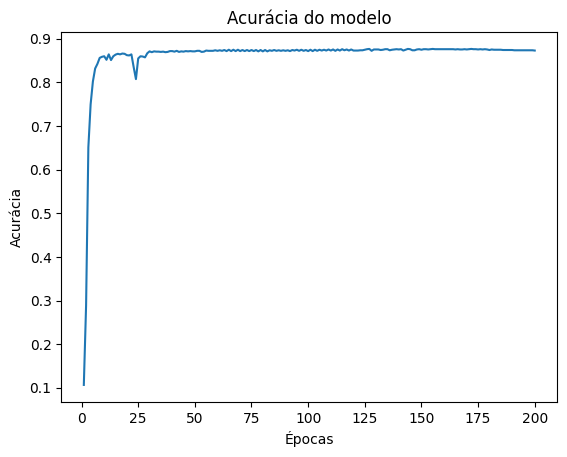

In [ ]:
# Plotando 
plt.plot(historico_epochs, historico_acc)
plt.title("Acurácia do modelo")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.show()